<a href="https://colab.research.google.com/github/saniahussain07/Business-Break-even-Scalability-Analysis/blob/main/Business_Break_Even_%26_Scalability_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#      ***Business*** ***Break***-***Even*** ***&***  ***Scalability*** ***Analysis***





AFC = FC/Quantity       
AVC = VC/Quantity       
ATC = TC/Quantity or AFC+AVC    
Fixed Cost(FC)-Rent,Salary   
Variable Cost(VC)-Raw material, Packaging  
TC = FC+VC



In [7]:
import numpy as np
import pandas as pd

# 1. Setup - Seed for reproducibility
np.random.seed(42)
n_rows = 10000

# 2. Generating Independent Variables
# Use np.random.normal for "Bell Curve" distributions (realistic sales)
# Mean sales: 50 units, Standard Deviation: 15
sales_volume = np.random.normal(50, 15, n_rows).astype(int)
sales_volume = np.clip(sales_volume, 1, 100) # Ensure no negative sales

# 3. Fixed Costs (Constant across the vector)
# Even if sales change, rent/salaries stay at 5000
fixed_costs = np.full(n_rows, 5000)

# 4. Unit Price and Variable Costs (Vectorized Math)
# Price fluctuates slightly due to discounts/market
unit_price = np.random.uniform(90, 110, n_rows)
unit_variable_cost = np.random.uniform(30, 40, n_rows)

# 5. The Calculations (THIS IS WHERE NUMPY SHINES)
# NO FOR LOOPS. We multiply the entire arrays at once.
total_revenue = sales_volume * unit_price
total_variable_costs = sales_volume * unit_variable_cost
total_costs = fixed_costs + total_variable_costs
profit = total_revenue - total_costs

# 6. Average Fixed Cost (Your core project metric)
# How much rent is "hidden" in each unit sold?
avg_fixed_cost = fixed_costs / sales_volume

# 7. Package into a DataFrame for Phase 2
df = pd.DataFrame ({
    'dates' : pd.date_range(end=pd.Timestamp.now(), periods=n_rows),
    'Sales_Volume': sales_volume,
    'Fixed_Costs': fixed_costs,
    'Unit_Price': unit_price,
    'Unit_Var_Cost': unit_variable_cost,
    'Total_Revenue': total_revenue,
    'Total_Costs': total_costs,
    'Profit': profit,
    'Avg_Fixed_Cost': avg_fixed_cost
})
# HINT FOR YOUR SCRIPT:
df['Cumulative_Profit'] = np.cumsum(df['Profit'])

# Find the break-even row
break_even_point = df[df['Cumulative_Profit'] > 0]
print("-"*30)
print(f"Dataset Generated: {df.shape[0]} rows.")
print("-"*30)
print(df.head().round(2))

------------------------------
Dataset Generated: 10000 rows.
------------------------------
                       dates  Sales_Volume  Fixed_Costs  Unit_Price  \
0 1998-11-21 07:12:15.472237            57         5000       96.43   
1 1998-11-22 07:12:15.472237            47         5000       92.06   
2 1998-11-23 07:12:15.472237            59         5000       91.44   
3 1998-11-24 07:12:15.472237            72         5000       91.89   
4 1998-11-25 07:12:15.472237            46         5000      101.66   

   Unit_Var_Cost  Total_Revenue  Total_Costs   Profit  Avg_Fixed_Cost  \
0          31.72        5496.23      6807.76 -1311.53           87.72   
1          33.47        4326.84      6573.00 -2246.16          106.38   
2          39.70        5394.73      7342.36 -1947.63           84.75   
3          37.81        6615.76      7722.17 -1106.41           69.44   
4          32.83        4676.24      6509.99 -1833.75          108.70   

   Cumulative_Profit  
0           -1311.

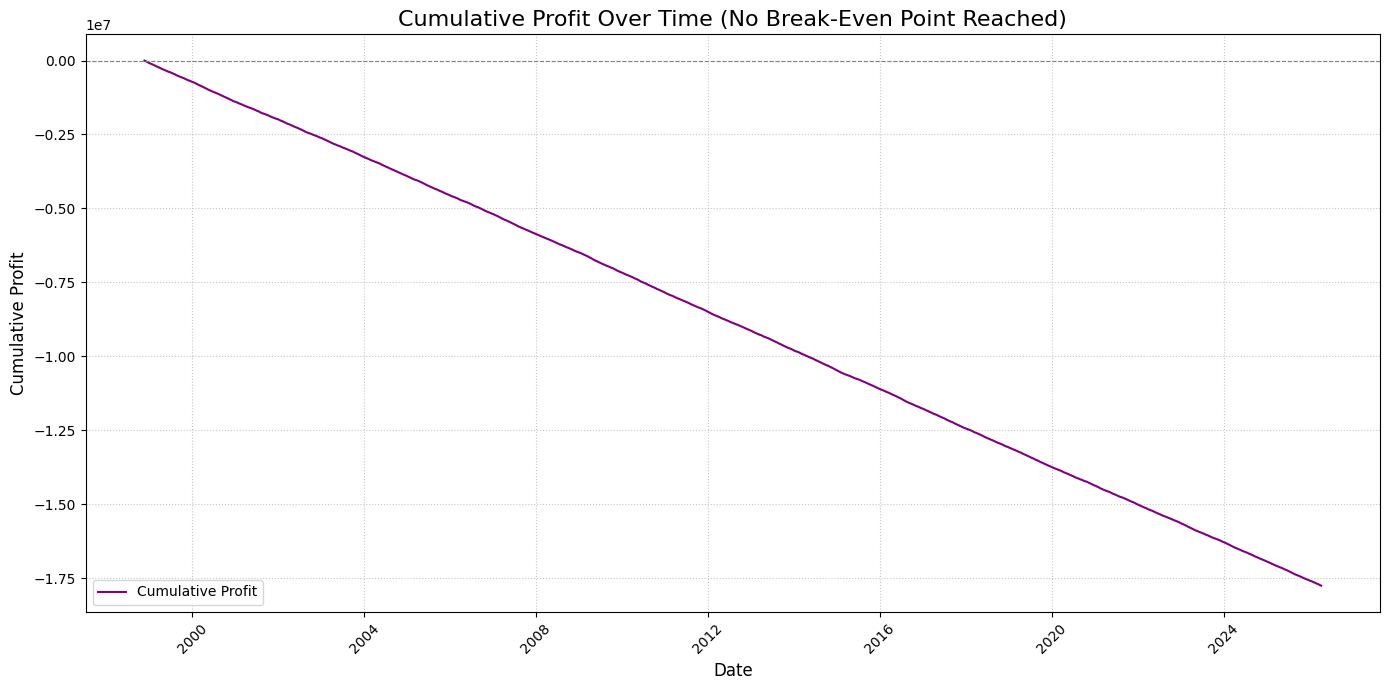

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Added for np.where

# FIND THE BREAK-EVEN POINT (Moved from another cell to ensure definition)
# Find the first index where Cumulative Profit becomes positive
be_mask = df['Cumulative_Profit'] > 0
if be_mask.any():
    be_idx = np.where(be_mask)[0][0]
    be_date = df.iloc[be_idx]['dates']
    be_value = df.iloc[be_idx]['Cumulative_Profit']
else:
    be_date = "Never became profitable."
    be_value = None # Not used if 'Never became profitable.', but good to set

plt.figure(figsize=(14, 7))
sns.lineplot(x='dates', y='Cumulative_Profit', data=df, color='purple', label='Cumulative Profit')

# Mark the break-even point if it exists
if be_date != "Never became profitable.":
    plt.scatter(be_date, be_value, color='red', s=150, zorder=5, label='Break-Even Point', edgecolor='black')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.title('Cumulative Profit Over Time with Break-Even Point', fontsize=16)
else:
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.title('Cumulative Profit Over Time (No Break-Even Point Reached)', fontsize=16)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Profit', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

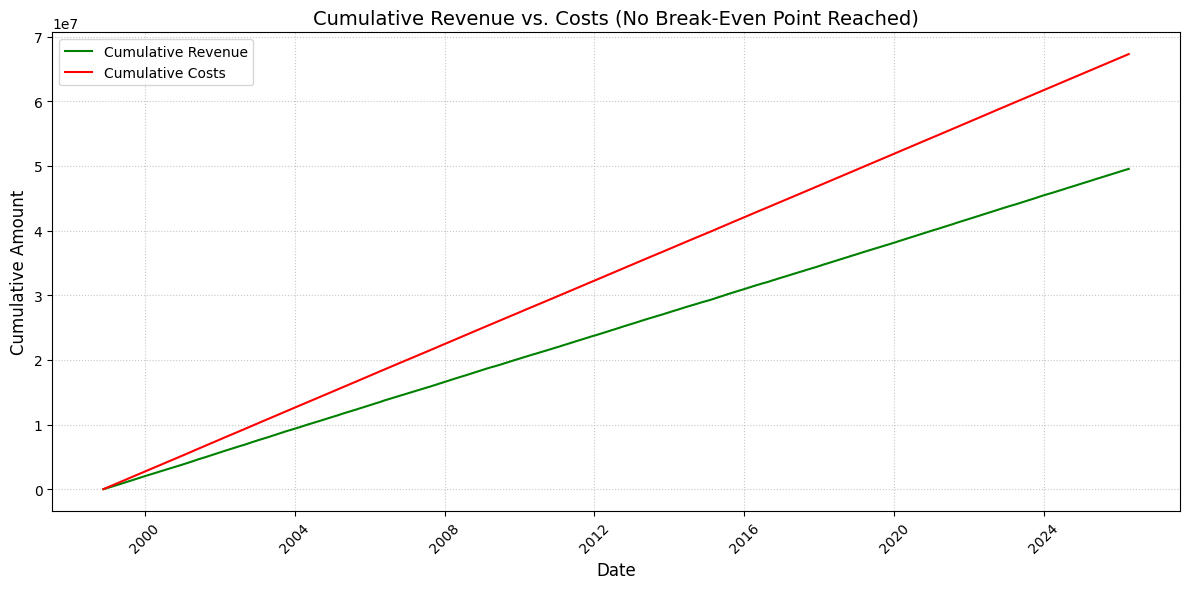

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

# Plot Total Revenue and Total Costs
plt.plot(df['dates'], np.cumsum(df['Total_Revenue']), label='Cumulative Revenue', color='green')
plt.plot(df['dates'], np.cumsum(df['Total_Costs']), label='Cumulative Costs', color='red')

# Recalculate break-even point to ensure variables are defined
be_mask = df['Cumulative_Profit'] > 0
if be_mask.any():
    be_idx = np.where(be_mask)[0][0]
    be_date = df.iloc[be_idx]['dates']
    be_cumulative_revenue_at_be = np.cumsum(df.iloc[:be_idx+1]['Total_Revenue']).iloc[-1]

    # Mark the Break-Even Point
    plt.scatter(be_date, be_cumulative_revenue_at_be,
                color='black', s=100, zorder=5, label='Break-Even Point')
    plt.title('Cumulative Revenue vs. Costs (Break-Even Analysis)', fontsize=14)
else:
    plt.title('Cumulative Revenue vs. Costs (No Break-Even Point Reached)', fontsize=14)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Amount', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# This finds the rows where Cumulative Profit finally crosses into positive territory
profitable_days = df[df['Cumulative_Profit'] > 0]

if not profitable_days.empty:
    first_profit_day = profitable_days.iloc[0]['dates']
    print(f"Congratulations! The business broke even on: {first_profit_day}")
else:
    print("The business is still bankrupt. Adjust your Fixed Costs or Sales Volume!")

The business is still bankrupt. Adjust your Fixed Costs or Sales Volume!


In [12]:
import numpy as np
import pandas as pd

# 1. Setup - Seed for reproducibility
np.random.seed(42)
n_rows = 10000

# 2. Generating Independent Variables
# Use np.random.normal for "Bell Curve" distributions (realistic sales)
# Mean sales: 50 units, Standard Deviation: 15
sales_volume = np.random.normal(50, 30, n_rows).astype(int)
sales_volume = np.clip(sales_volume, 1, 100) # Ensure no negative sales

# 3. Fixed Costs (Constant across the vector)
# Even if sales change, rent/salaries stay at 5000
fixed_costs = np.full(n_rows, 2000)

# 4. Unit Price and Variable Costs (Vectorized Math)
# Price fluctuates slightly due to discounts/market
unit_price = np.random.uniform(90, 110, n_rows)
unit_variable_cost = np.random.uniform(40, 60, n_rows)

# 5. The Calculations (THIS IS WHERE NUMPY SHINES)
# NO FOR LOOPS. We multiply the entire arrays at once.
total_revenue = sales_volume * unit_price
total_variable_costs = sales_volume * unit_variable_cost
total_costs = fixed_costs + total_variable_costs
profit = total_revenue - total_costs

# 6. Average Fixed Cost (Your core project metric)
# How much rent is "hidden" in each unit sold?
avg_fixed_cost = fixed_costs / sales_volume

# 7. Package into a DataFrame for Phase 2
df = pd.DataFrame ({
    'dates' : pd.date_range(end=pd.Timestamp.now(), periods=n_rows),
    'Sales_Volume': sales_volume,
    'Fixed_Costs': fixed_costs,
    'Unit_Price': unit_price,
    'Unit_Var_Cost': unit_variable_cost,
    'Total_Revenue': total_revenue,
    'Total_Costs': total_costs,
    'Profit': profit,
    'Avg_Fixed_Cost': avg_fixed_cost
})
# HINT FOR YOUR SCRIPT:
df['Cumulative_Profit'] = np.cumsum(df['Profit'])

# Find the break-even row
break_even_point = df[df['Cumulative_Profit'] > 0]
print("-"*30)
print(f"we increases sales and decreases fixed cost.")
print("-"*30)
print(df.head().round(2))

------------------------------
we increases sales and decreases fixed cost.
------------------------------
                       dates  Sales_Volume  Fixed_Costs  Unit_Price  \
0 1998-11-21 07:12:59.859498            64         2000       96.43   
1 1998-11-22 07:12:59.859498            45         2000       92.06   
2 1998-11-23 07:12:59.859498            69         2000       91.44   
3 1998-11-24 07:12:59.859498            95         2000       91.89   
4 1998-11-25 07:12:59.859498            42         2000      101.66   

   Unit_Var_Cost  Total_Revenue  Total_Costs   Profit  Avg_Fixed_Cost  \
0          43.43        6171.21      4779.53  1391.67           31.25   
1          46.94        4142.72      4112.12    30.60           44.44   
2          59.40        6309.09      6098.74   210.35           28.99   
3          55.62        8729.12      7283.50  1445.63           21.05   
4          45.65        4269.61      3917.38   352.23           47.62   

   Cumulative_Profit  
0   

In [13]:
# 1. The Date of the very first positive cumulative profit
# (In your new data, this might be row 0!)
profitable_rows = df[df['Cumulative_Profit'] > 0]

if not profitable_rows.empty:
    be_date = profitable_rows.iloc[0]['dates']
    print(f"Business became profitable on: {be_date}")
else:
    be_date = "Never became profitable."
    print(f"Business became profitable on: {be_date}") # Print this message when it doesn't break even

# 2. The Maximum "Drawdown"
# (What was the most money the business was ever 'in the hole'?)
max_loss = df['Cumulative_Profit'].min()

# 3. Final Total Profit
total_end_profit = df['Cumulative_Profit'].iloc[-1]

# print(f"Business became profitable on: {be_date}") # This print is now inside the if/else
print(f"Deepest point of debt: {round(max_loss, 2)}")
print(f"Final Bank Balance after 10,000 days: {round(total_end_profit, 2)}")

Business became profitable on: 1998-11-21 07:12:59.859498
Deepest point of debt: 1391.67
Final Bank Balance after 10,000 days: 4875824.39


In [14]:
# Calculate Cumulative Profit
df['Cumulative_Profit'] = np.cumsum(df['Profit'])

# FIND THE BREAK-EVEN POINT
# Find the first index where Cumulative Profit becomes positive
be_mask = df['Cumulative_Profit'] > 0
if be_mask.any():
    be_idx = np.where(be_mask)[0][0]
    be_date = df.iloc[be_idx]['dates']
    be_value = df.iloc[be_idx]['Cumulative_Profit']

    print(f"--- BREAK-EVEN ANALYSIS ---")
    print(f"Break-Even Date: {be_date}")
    print(f"Days to Profitability: {be_idx}")
else:
    print("Business never broke even. Increase growth or decrease fixed costs!")

--- BREAK-EVEN ANALYSIS ---
Break-Even Date: 1998-11-21 07:12:59.859498
Days to Profitability: 0


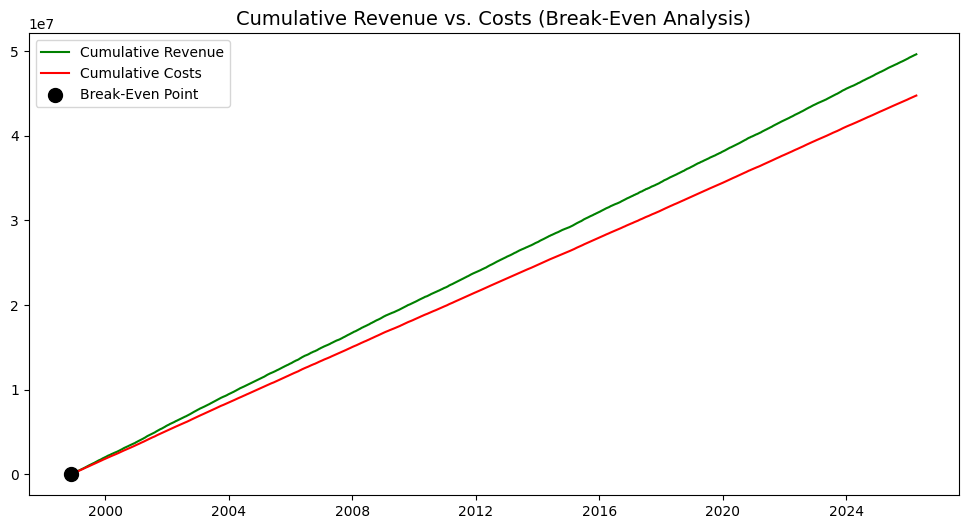

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot Total Revenue and Total Costs
plt.plot(df['dates'], np.cumsum(df['Total_Revenue']), label='Cumulative Revenue', color='green')
plt.plot(df['dates'], np.cumsum(df['Total_Costs']), label='Cumulative Costs', color='red')

# Mark the Break-Even Point
# Use .iloc[-1] to correctly get the last element by position from the resulting Series
plt.scatter(be_date, np.cumsum(df.iloc[:be_idx+1]['Total_Revenue']).iloc[-1],
            color='black', s=100, zorder=5, label='Break-Even Point')

plt.title('Cumulative Revenue vs. Costs (Break-Even Analysis)', fontsize=14)
plt.legend()
plt.show()

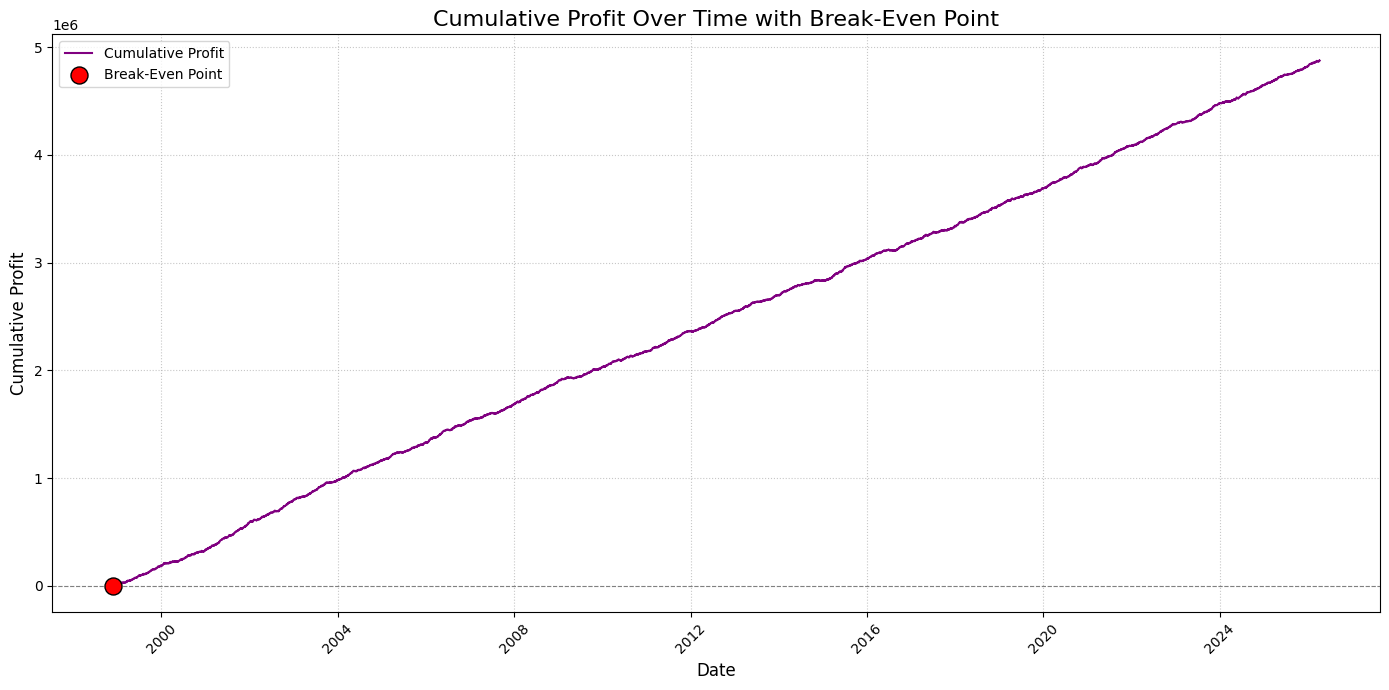

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='dates', y='Cumulative_Profit', data=df, color='purple', label='Cumulative Profit')

# Mark the break-even point if it exists
if be_date != "Never became profitable.":
    plt.scatter(be_date, be_value, color='red', s=150, zorder=5, label='Break-Even Point', edgecolor='black')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.title('Cumulative Profit Over Time with Break-Even Point', fontsize=16)
else:
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.title('Cumulative Profit Over Time (No Break-Even Point Reached)', fontsize=16)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Profit', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
import numpy as np
import pandas as pd

# 1. Setup with high initial costs and growth
np.random.seed(42) # For reproducibility, consistent with previous cells
n_rows = 10000 # Define n_rows for self-containment, consistent with previous cells

fixed_costs = np.full(n_rows, 5000)
sales_growth = np.linspace(30, 200, n_rows).astype(int) # Start low, end high
sales_volume = sales_growth + np.random.normal(0, 5, n_rows).astype(int)
sales_volume = np.clip(sales_volume, 1, None) # Ensure sales volume is at least 1

# Define unit_price and unit_variable_cost for self-containment, consistent with previous cells
unit_price = np.random.uniform(90, 110, n_rows)
unit_variable_cost = np.random.uniform(40, 60, n_rows)

# 2. Fresh Calculations
total_revenue = sales_volume * unit_price
total_variable_costs = sales_volume * unit_variable_cost
total_costs = fixed_costs + total_variable_costs
daily_profit = total_revenue - total_costs
avg_fixed_cost = fixed_costs / sales_volume

# Create the DataFrame
df = pd.DataFrame ({
    'dates' : pd.date_range(end=pd.Timestamp.now(), periods=n_rows),
    'Sales_Volume': sales_volume,
    'Fixed_Costs': fixed_costs,
    'Unit_Price': unit_price,
    'Unit_Var_Cost': unit_variable_cost,
    'Total_Revenue': total_revenue,
    'Total_Costs': total_costs,
    'Profit': daily_profit,
    'Avg_Fixed_Cost': avg_fixed_cost
})

# Calculate Cumulative Profit after DataFrame creation
df['Cumulative_Profit'] = np.cumsum(df['Profit'])

print("--- RECALCULATION COMPLETE (CLEAN DATA) ---")
print(df[['dates', 'Sales_Volume', 'Profit', 'Cumulative_Profit']].tail(10).round(2))

--- RECALCULATION COMPLETE (CLEAN DATA) ---
                          dates  Sales_Volume   Profit  Cumulative_Profit
9990 2026-03-29 07:18:13.694367           206  4991.32         7520188.41
9991 2026-03-30 07:18:13.694367           199  6449.35         7526637.77
9992 2026-03-31 07:18:13.694367           202  6360.96         7532998.73
9993 2026-04-01 07:18:13.694367           192  5359.00         7538357.73
9994 2026-04-02 07:18:13.694367           204  7290.61         7545648.34
9995 2026-04-03 07:18:13.694367           205  6492.23         7552140.57
9996 2026-04-04 07:18:13.694367           190  5476.56         7557617.13
9997 2026-04-05 07:18:13.694367           196  3012.55         7560629.68
9998 2026-04-06 07:18:13.694367           201  5486.80         7566116.48
9999 2026-04-07 07:18:13.694367           203  5223.44         7571339.92


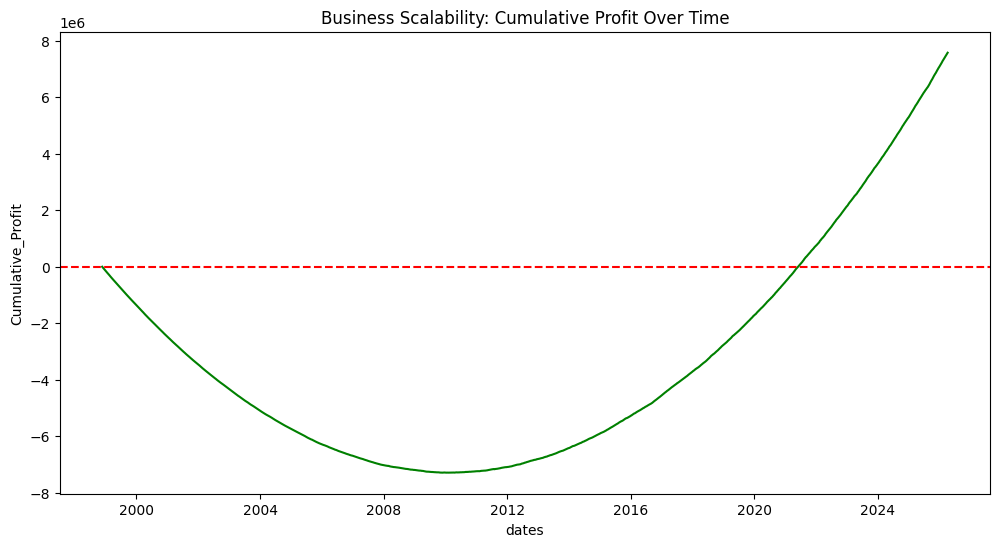

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='dates', y='Cumulative_Profit', color='green')
plt.axhline(0, color='red', linestyle='--') # The Break-Even Line
plt.title('Business Scalability: Cumulative Profit Over Time')
plt.show()

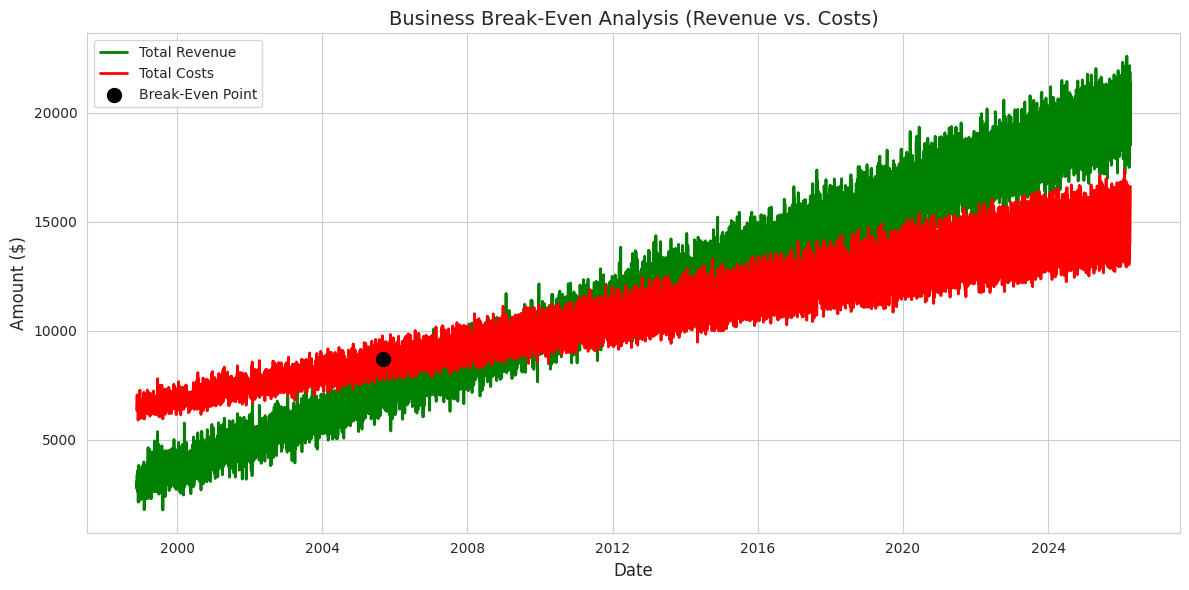

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a professional look
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# 1. Plot the two main lines
sns.lineplot(data=df, x='dates', y='Total_Revenue', label='Total Revenue', color='green', linewidth=2)
sns.lineplot(data=df, x='dates', y='Total_Costs', label='Total Costs', color='red', linewidth=2)

# 2. Add the Break-Even Point (where Profit first becomes >= 0)
break_even_row = df[df['Profit'] >= 0].iloc[0]
plt.scatter(break_even_row['dates'], break_even_row['Total_Revenue'],
            color='black', s=100, label='Break-Even Point', zorder=5)

# 3. Final Touches
plt.title('Business Break-Even Analysis (Revenue vs. Costs)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()